In [61]:
import pandas as pd 
import numpy as np 
import matplotlib as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor 

import pickle




In [2]:
df = pd.read_csv('demand_forecasting.csv')

In [3]:
df.columns


Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [4]:
features = ['Category', 
       'Inventory Level', 
       'Price',
       'Discount',
       'Promotion', 
       'Competitor Pricing'
]

In [5]:
features

['Category',
 'Inventory Level',
 'Price',
 'Discount',
 'Promotion',
 'Competitor Pricing']

In [6]:
target = ['Demand']

In [7]:
X = df[features].copy()

In [8]:
Y = df[target].copy()

In [9]:
label_encoders = {}

categorical_cols = X.select_dtypes(include=['object']).columns

In [10]:
categorical_cols

Index(['Category'], dtype='object')

In [11]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [12]:
label_encoders

{'Category': LabelEncoder()}

In [13]:
Xtrain, Xtest, Ytrain , Ytest = train_test_split(X,Y, test_size=0.2)

In [14]:
X

,Category,Inventory Level,Price,Discount,Promotion,Competitor Pricing
0,1,195,72.72,5,0,85.73
1,0,117,80.16,15,1,92.02
2,0,247,62.94,10,1,60.08
3,1,139,87.63,10,0,85.19
4,3,152,54.41,0,0,51.63
...,...,...,...,...,...,...
75995,4,233,29.80,5,0,32.23
75996,4,137,42.92,5,0,40.73
75997,0,197,17.81,10,0,19.41
75998,2,125,151.72,0,0,143.71


In [15]:
Y

,Demand
0,115
1,229
2,157
3,52
4,59
...,...
75995,64
75996,137
75997,68
75998,84


In [27]:
xgb = XGBRegressor( objective = 'SquaredError', n_jobs = 1) 

In [28]:
param_dict = {
    "n_estimators": [200,300,500],
    "max_depth": [3,4,6,8],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.7,0.8,1.0],
    "colsample_bytrees": [0.7,0.8,1.0],
    "min_child_weight": [1,3,5]
}

In [37]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dict,
    n_iter = 25, 
    scoring = 'neg_mean_absolute_error',
    cv = 3,
    verbose = 1,
    n_jobs = 1
)

In [38]:
random_search.fit(Xtrain, Ytrain)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/Users/rojisah/micromamba/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [04:47:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "colsample_bytrees" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/rojisah/micromamba/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [04:47:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "colsample_bytrees" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/rojisah/micromamba/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [04:47:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "colsample_bytrees" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/rojisah/micromamba/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [04:47:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "colsample_bytrees" } are not used.

  warnings.warn(smsg, UserWarning)


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=1,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=25, n_jobs=1,
                   param_distributions={'colsample_bytrees': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [40]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytrees': 0.7}

In [41]:
best_model = random_search.best_estimator_

In [43]:
y_pred = best_model.predict(Xtest)

In [54]:
mse = mean_squared_error(Ytest, y_pred)

In [56]:
sqrt = np.sqrt(mse)
print(sqrt)

35.99445385066722


In [57]:
best_model.feature_importances_

array([0.2438802 , 0.01906764, 0.06955869, 0.01939811, 0.6256727 ,
       0.02242263], dtype=float32)

In [58]:
feature_importances = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

In [59]:
feature_importances

Promotion             0.625673
Category              0.243880
Price                 0.069559
Competitor Pricing    0.022423
Discount              0.019398
Inventory Level       0.019068
dtype: float32

<Axes: title={'center': 'Feature Importance'}>

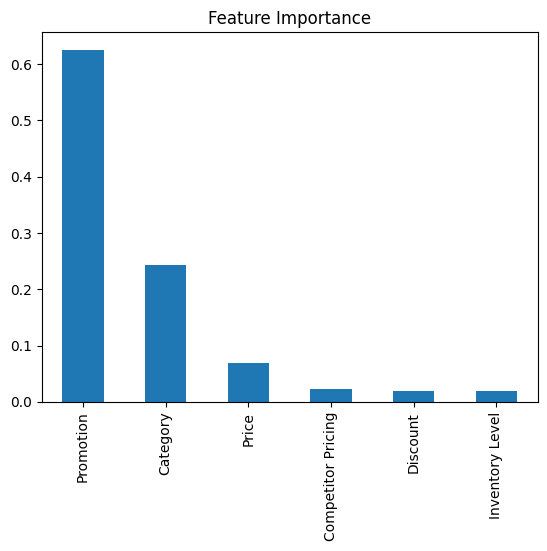

In [65]:
feature_importances.plot(kind ='bar',title = 'Feature Importance')


In [66]:
with open('label_encoders.pkl','wb') as f:
    pickle.dump(label_encoders,f)

In [67]:
with open('xgboost_demand_model.pkl','wb') as f:
    pickle.dump(best_model, f)